In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import io
import json
import os
import re
import numpy as np 

In [99]:
rag_json_path = 'results/subset_accuracies_v4_reasoning_fct.json'
no_rag_json_path = 'results_no_rag/subset_accuracies_report_tasks_reasoning_fct.json'
rag_report_path = 'results/final_summary_report_tasks_reasoning_fct.csv'
no_rag_report_path = 'results_no_rag/final_summary_report_tasks_reasoning_fct.csv'
plots_dir = "thesis_visualizations"
os.makedirs(plots_dir, exist_ok=True)

In [100]:
try:
    with open(rag_json_path, 'r') as f:
        rag_json = json.load(f)
    print(f"Successfully loaded subset accuracy data from {rag_json_path}")
except FileNotFoundError:
    print(f"ERROR: Subset JSON file not found at '{rag_json_path}'. Please check the path.")
    # Create an empty dictionary to prevent crashes
    rag_json = {}
except json.JSONDecodeError:
    print(f"ERROR: The file at '{rag_json_path}' is not a valid JSON. Please check the file.")
    rag_json = {}


Successfully loaded subset accuracy data from results/subset_accuracies_v4_reasoning_fct.json


In [101]:
# --- 2. DATA WRANGLING FOR DISTRIBUTION ANALYSIS ---
# Convert the JSON into a "tidy" DataFrame suitable for seaborn plotting.
subset_data_list = []
for key, accuracies in rag_json.items():
    # --- THIS IS THE KEY FILTER ---
    # Only include runs that have a meaningful distribution (more than 10 subsets)
    if len(accuracies) > 10:
        # Parse the key to get metadata
        parts = key.split('_')
        task_name = f"{parts[0]}_{parts[1]}"
        
        # Reconstruct model name and prompt ID from the key
        model_name_raw = "_".join(parts[2:-1])
        prompt_id_match = re.search(r'(v\d+)$', model_name_raw)
        if prompt_id_match:
            prompt_id = prompt_id_match.group(1)
            model_name = model_name_raw.replace(f"_{prompt_id}", "")
        else:
            prompt_id = "unknown"
            model_name = model_name_raw

        for acc in accuracies:
            subset_data_list.append({
                "model_name": model_name,
                "prompt_id": prompt_id,
                "accuracy": acc,
                "run_id": f"{model_name} | {prompt_id}" # Create a unique ID for each run
            })
if not subset_data_list:
    print("\nERROR: No experimental runs with more than 10 subsets were found in the JSON file.")
    print("Cannot generate the distribution plot.")
else:
    subset_df = pd.DataFrame(subset_data_list)

/tmp/ipykernel_797082/3737889227.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


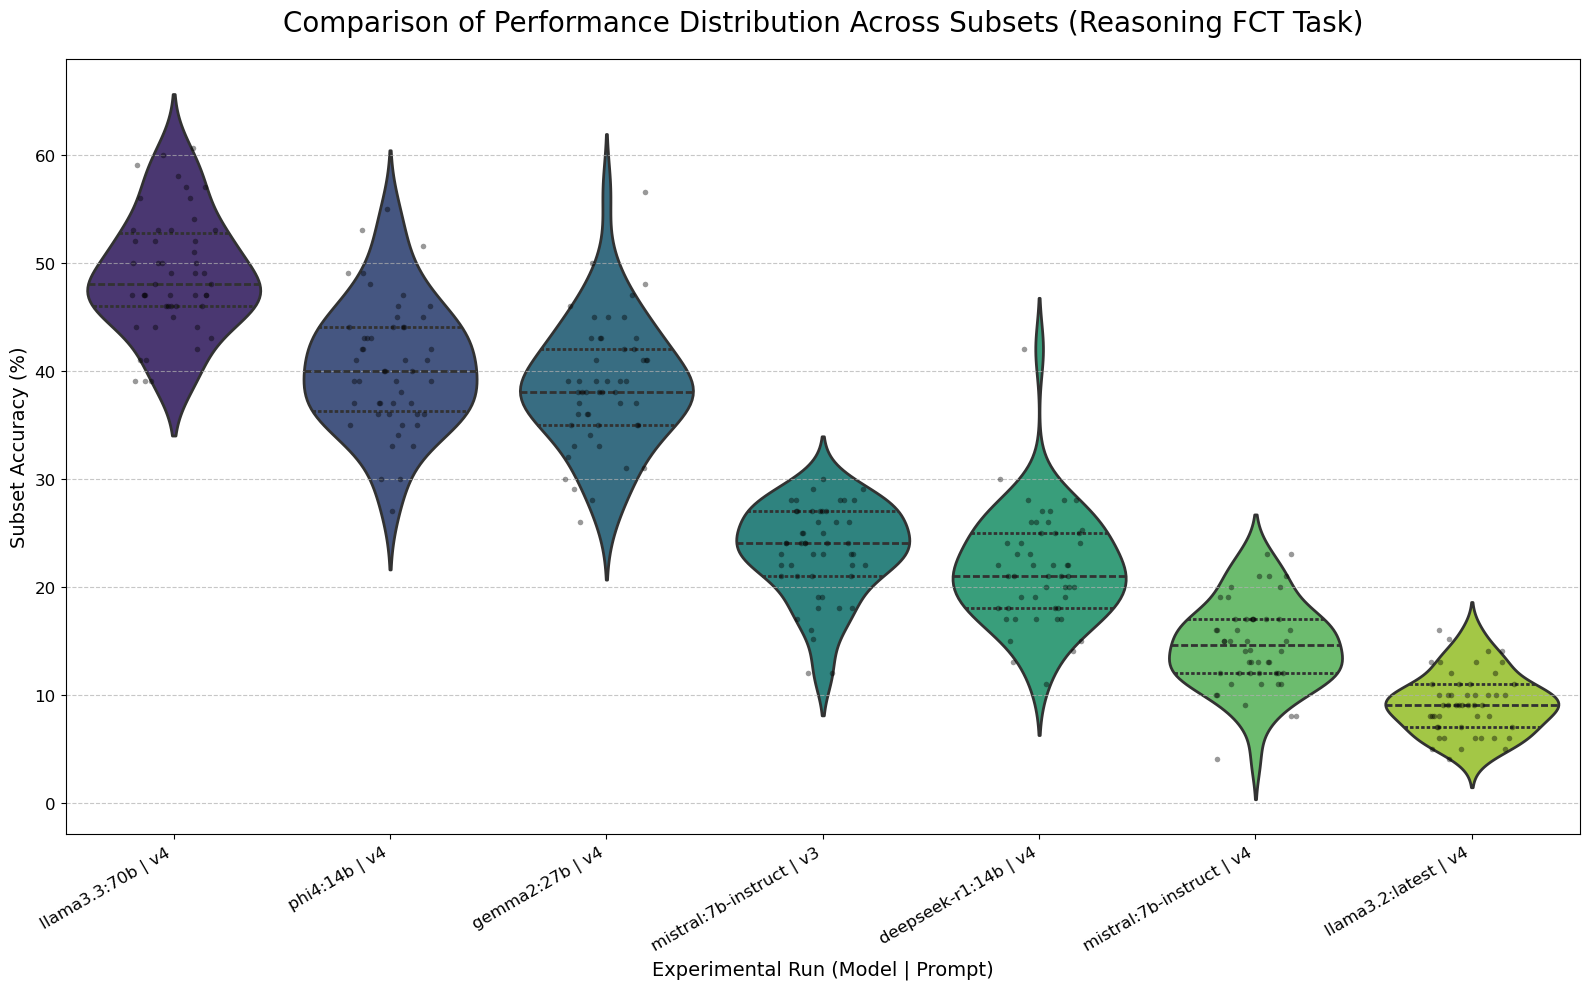

In [102]:
# === THE DEFINITIVE PLOT: VIOLIN PLOT WITH STRIP PLOT OVERLAY ===

# For a professional-looking chart, we sort the runs by their median performance.
median_accuracies = subset_df.groupby('run_id')['accuracy'].median().sort_values(ascending=False)
sorted_order = median_accuracies.index

plt.figure(figsize=(16, 10))

# a) Create the Violin Plot to show the shape of the distribution
sns.violinplot(
    data=subset_df,
    x='run_id',
    y='accuracy',
    order=sorted_order,
    palette='viridis',
    inner='quartile', # Shows the median and quartiles inside the violin
    linewidth=2
)

# b) Overlay a Strip Plot to show every individual data point
sns.stripplot(
    data=subset_df,
    x='run_id',
    y='accuracy',
    order=sorted_order,
    color='black',
    alpha=0.4, # Make points semi-transparent
    jitter=0.2, # Spread points horizontally to avoid overlap
    size=4
)

plt.title('Comparison of Performance Distribution Across Subsets (Reasoning FCT Task)', fontsize=20, pad=20)
plt.xlabel('Experimental Run (Model | Prompt)', fontsize=14)
plt.ylabel('Subset Accuracy (%)', fontsize=14)
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

In [103]:
plot_path = os.path.join(plots_dir, 'distribution_comparison_violinplot.png')
plt.savefig(plot_path)
plt.close()

print(f"\nSuccessfully generated and saved the distribution plot to: {plot_path}")


Successfully generated and saved the distribution plot to: thesis_visualizations/distribution_comparison_violinplot.png


In [104]:
summary_df = pd.read_csv(rag_report_path)

In [105]:
full_runs_df = summary_df[summary_df['total_samples'] > 101].copy()
prompt_runs_df = summary_df[summary_df['total_samples'] <= 101].copy()


/tmp/ipykernel_797082/227808059.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


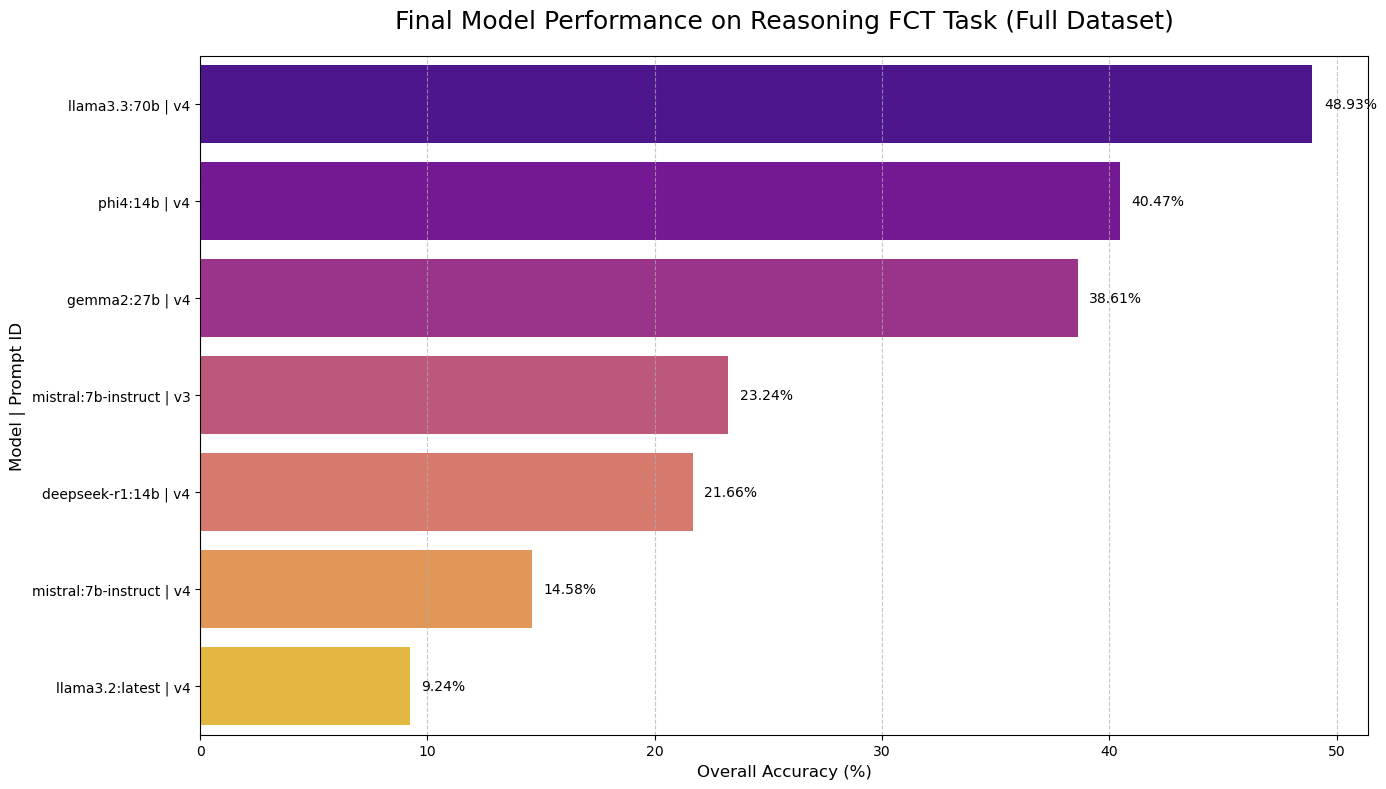

Saved Plot 1 to thesis_visualizations/1_final_model_performance.png


In [106]:
# === PLOT 1: MAIN PERFORMANCE BAR CHART (Full Runs) ===
# This plot answers: "Which model performed best overall on the full dataset?"
full_runs_df['run_id'] = full_runs_df['model_name'] + ' | ' + full_runs_df['prompt_id']
full_runs_df_sorted = full_runs_df.sort_values('overall_accuracy_%', ascending=False)

plt.figure(figsize=(14, 8))
bar_plot = sns.barplot(
    data=full_runs_df_sorted,
    x='overall_accuracy_%',
    y='run_id',
    palette='plasma'
)
plt.title('Final Model Performance on Reasoning FCT Task (Full Dataset)', fontsize=18, pad=20)
plt.xlabel('Overall Accuracy (%)', fontsize=12)
plt.ylabel('Model | Prompt ID', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
# Add labels to the end of the bars
for p in bar_plot.patches:
    width = p.get_width()
    plt.text(width + 0.5, p.get_y() + p.get_height() / 2, f'{width:.2f}%', va='center')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '1_final_model_performance.png'))
plt.show()
plt.close()
print(f"Saved Plot 1 to {plots_dir}/1_final_model_performance.png")


--- Generating Plot 2: Prompt Impact Heatmap ---


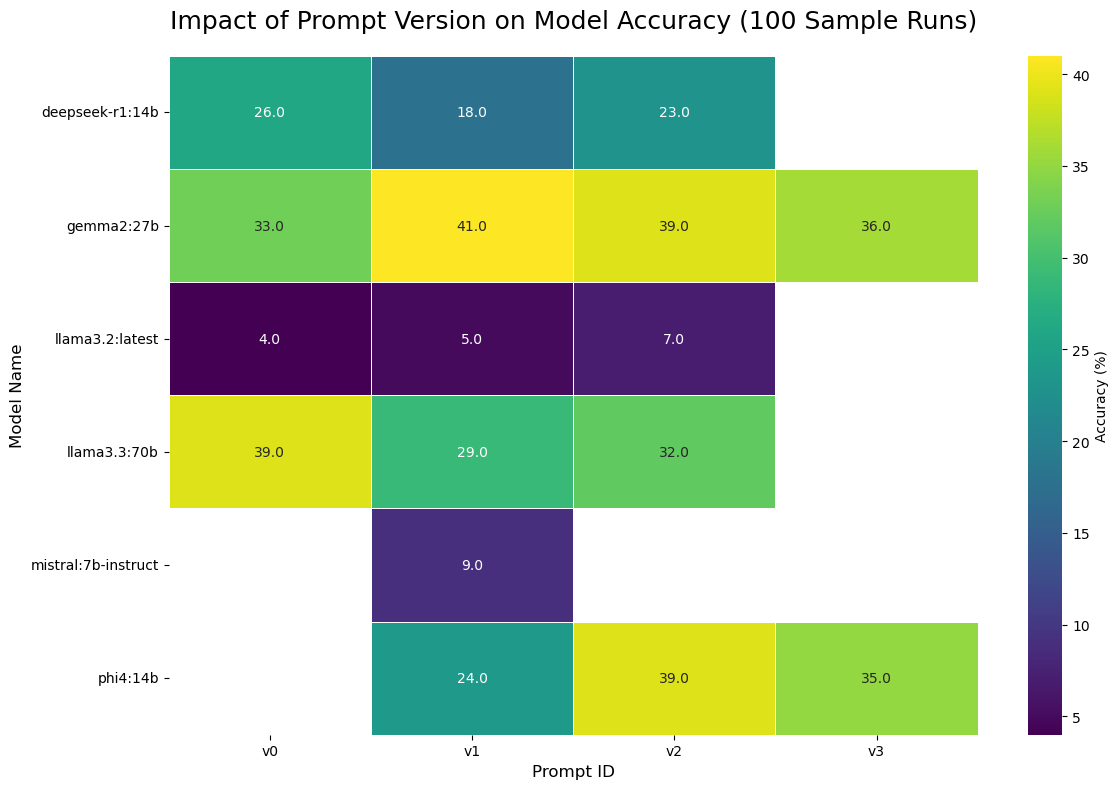

Saved Plot 2 to thesis_visualizations/2_prompt_impact_heatmap.png


In [107]:
# === PLOT 2: PROMPT ENGINEERING HEATMAP (Partial Runs) ===
print("\n--- Generating Plot 2: Prompt Impact Heatmap ---")
pivot_df = prompt_runs_df.pivot(index='model_name', columns='prompt_id', values='overall_accuracy_%')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="viridis", linewidths=.5, cbar_kws={'label': 'Accuracy (%)'})
plt.title('Impact of Prompt Version on Model Accuracy (100 Sample Runs)', fontsize=18, pad=20)
plt.xlabel('Prompt ID', fontsize=12)
plt.ylabel('Model Name', fontsize=12)
plt.tight_layout()

plt.savefig(os.path.join(plots_dir, '2_prompt_impact_heatmap.png'))
plt.show()
plt.close()
print(f"Saved Plot 2 to {plots_dir}/2_prompt_impact_heatmap.png")



--- Generating Plot 3: Accuracy vs. Consistency ---


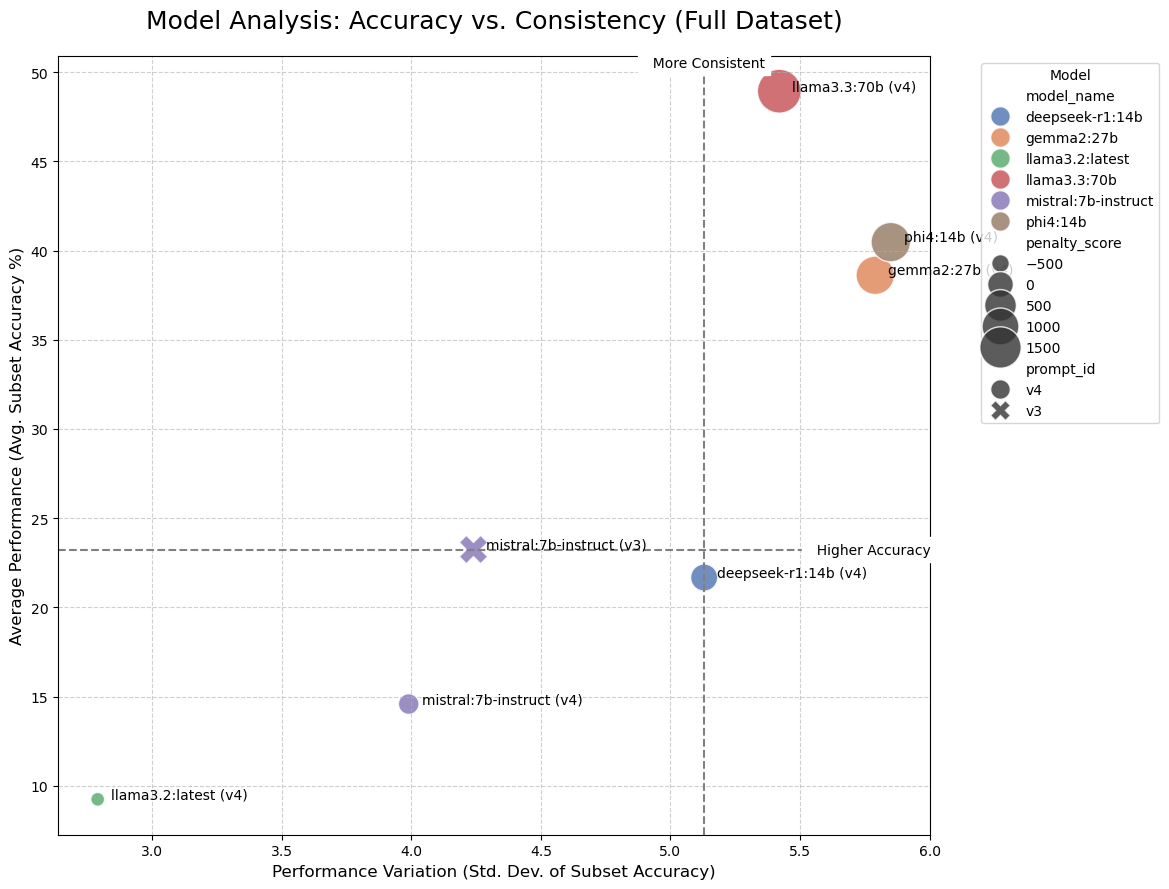

Saved Plot 3 to thesis_visualizations/3_accuracy_vs_consistency.png


In [108]:
# === PLOT 3: ACCURACY VS. CONSISTENCY SCATTER PLOT (Full Runs) ===
print("\n--- Generating Plot 3: Accuracy vs. Consistency ---")
plt.figure(figsize=(14, 9))
scatter_plot = sns.scatterplot(
    data=full_runs_df, x='std_dev_subset_accuracy', y='avg_subset_accuracy_%',
    hue='model_name', size='penalty_score', sizes=(100, 1000),
    alpha=0.8, palette='deep', style='prompt_id', s=200
)
for i in range(full_runs_df.shape[0]):
    plt.text(
        x=full_runs_df['std_dev_subset_accuracy'].iloc[i] + 0.05,
        y=full_runs_df['avg_subset_accuracy_%'].iloc[i] + 0.05,
        s=f"{full_runs_df['model_name'].iloc[i]} ({full_runs_df['prompt_id'].iloc[i]})"
    )
plt.title('Model Analysis: Accuracy vs. Consistency (Full Dataset)', fontsize=18, pad=20)
plt.xlabel('Performance Variation (Std. Dev. of Subset Accuracy)', fontsize=12)
plt.ylabel('Average Performance (Avg. Subset Accuracy %)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axhline(y=full_runs_df['avg_subset_accuracy_%'].median(), color='grey', linestyle='--')
plt.axvline(x=full_runs_df['std_dev_subset_accuracy'].median(), color='grey', linestyle='--')
plt.text(plt.xlim()[1], full_runs_df['avg_subset_accuracy_%'].median(), '  Higher Accuracy', va='center', ha='right', backgroundcolor='w')
plt.text(full_runs_df['std_dev_subset_accuracy'].median(), plt.ylim()[1], '  More Consistent', va='top', ha='center', backgroundcolor='w')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Model')
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig(os.path.join(plots_dir, '3_accuracy_vs_consistency.png'))
plt.show()
plt.close()
print(f"Saved Plot 3 to {plots_dir}/3_accuracy_vs_consistency.png")

In [109]:
summary_df

,model_name,task_name,prompt_id,kg_rag,total_samples,correct,wrong,overall_accuracy_%,avg_subset_accuracy_%,std_dev_subset_accuracy,penalty_score
0,deepseek-r1:14b,reasoning_fct,v0,yes,100,26,74,26.00,26.00,0.00,7.50
1,deepseek-r1:14b,reasoning_fct,v1,yes,100,18,82,18.00,18.00,0.00,-2.50
2,deepseek-r1:14b,reasoning_fct,v2,yes,100,23,77,23.00,23.00,0.00,3.75
3,deepseek-r1:14b,reasoning_fct,v4,yes,4999,1083,3916,21.66,21.67,5.13,104.00
4,gemma2:27b,reasoning_fct,v0,yes,100,33,67,33.00,33.00,0.00,16.25
5,gemma2:27b,reasoning_fct,v1,yes,100,41,59,41.00,41.00,0.00,26.25
6,gemma2:27b,reasoning_fct,v2,yes,100,39,61,39.00,39.00,0.00,23.75
7,gemma2:27b,reasoning_fct,v3,yes,100,36,64,36.00,36.00,0.00,20.00
8,gemma2:27b,reasoning_fct,v4,yes,4999,1930,3069,38.61,38.61,5.79,1162.75
9,llama3.2:latest,reasoning_fct,v0,yes,100,4,96,4.00,4.00,0.00,-20.00


In [110]:
rag_full_runs = summary_df[summary_df['total_samples'] > 101].copy()

In [111]:
no_rag_summary_df = pd.read_csv(no_rag_report_path)

In [112]:
# For each model, find the single best-performing run in each category (RAG vs. No-RAG).
# We use `loc` and `idxmax()` to find the row with the highest accuracy for each group.
best_rag_runs = rag_full_runs.loc[rag_full_runs.groupby('model_name')['overall_accuracy_%'].idxmax()]
best_no_rag_runs = no_rag_summary_df.loc[no_rag_summary_df.groupby('model_name')['overall_accuracy_%'].idxmax()]

In [113]:
# Combine these "best of" results into a final DataFrame for plotting.
comparison_df = pd.concat([best_rag_runs, best_no_rag_runs], ignore_index=True)

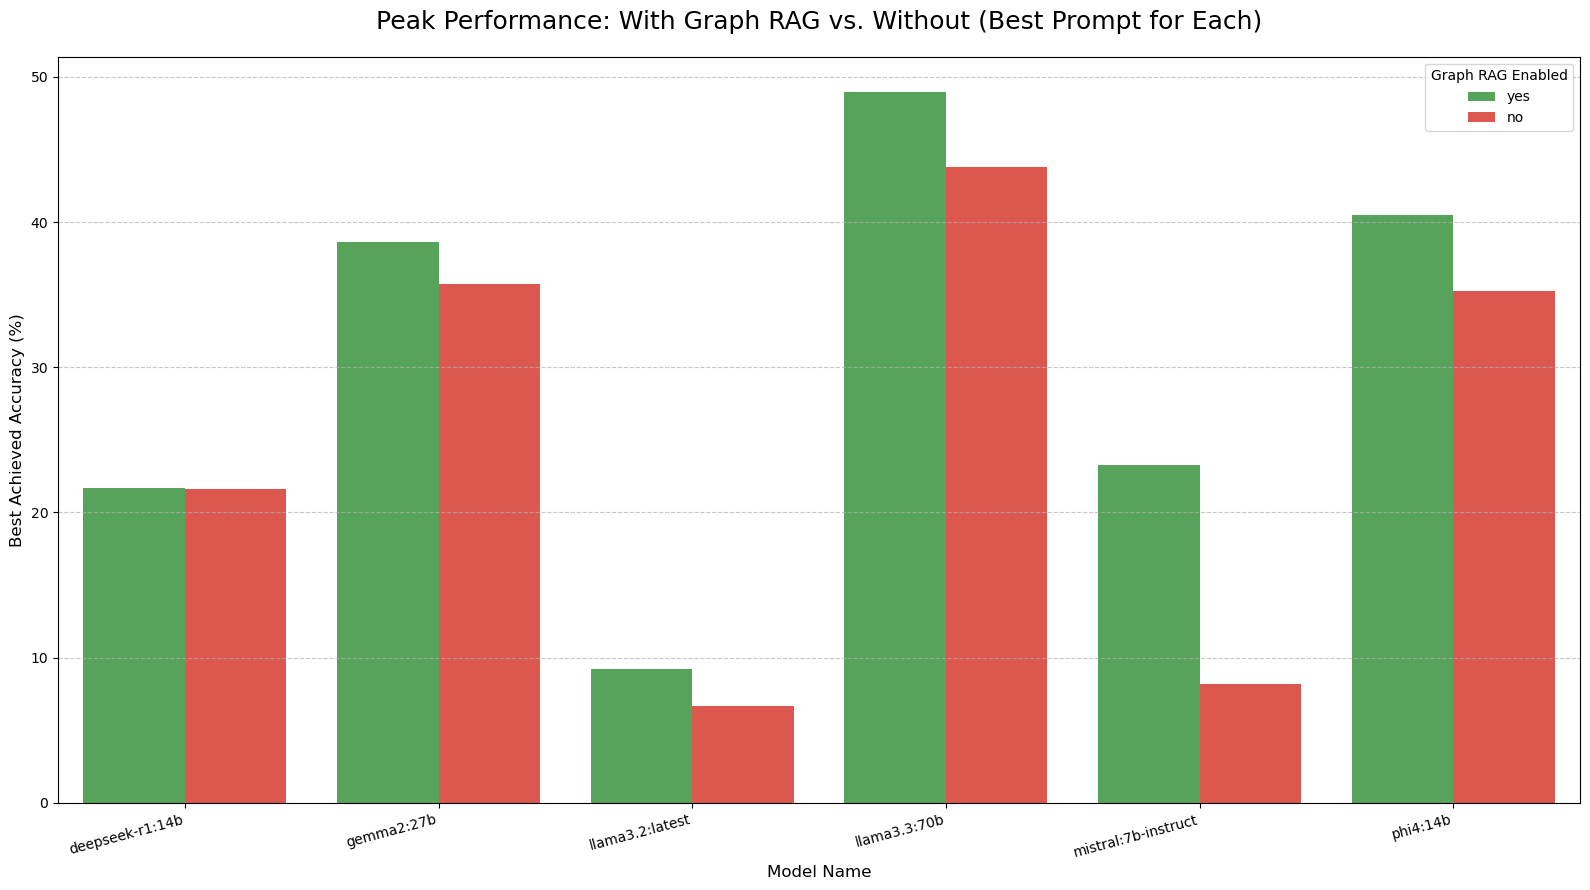

Saved Plot 1 to thesis_visualizations/1_best_vs_best_comparison_bar.png


In [114]:
# === PLOT 1: GROUPED BAR CHART - The Definitive "Best vs. Best" Comparison ===
plt.figure(figsize=(16, 9))
sns.barplot(
    data=comparison_df,
    x='model_name',
    y='overall_accuracy_%',
    hue='kg_rag',
    palette={'yes': '#4CAF50', 'no': '#F44336'} # Professional green and red
)
plt.title('Peak Performance: With Graph RAG vs. Without (Best Prompt for Each)', fontsize=18, pad=20)
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('Best Achieved Accuracy (%)', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.legend(title='Graph RAG Enabled')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '1_best_vs_best_comparison_bar.png'))
plt.show()
plt.close()
print(f"Saved Plot 1 to {plots_dir}/1_best_vs_best_comparison_bar.png")

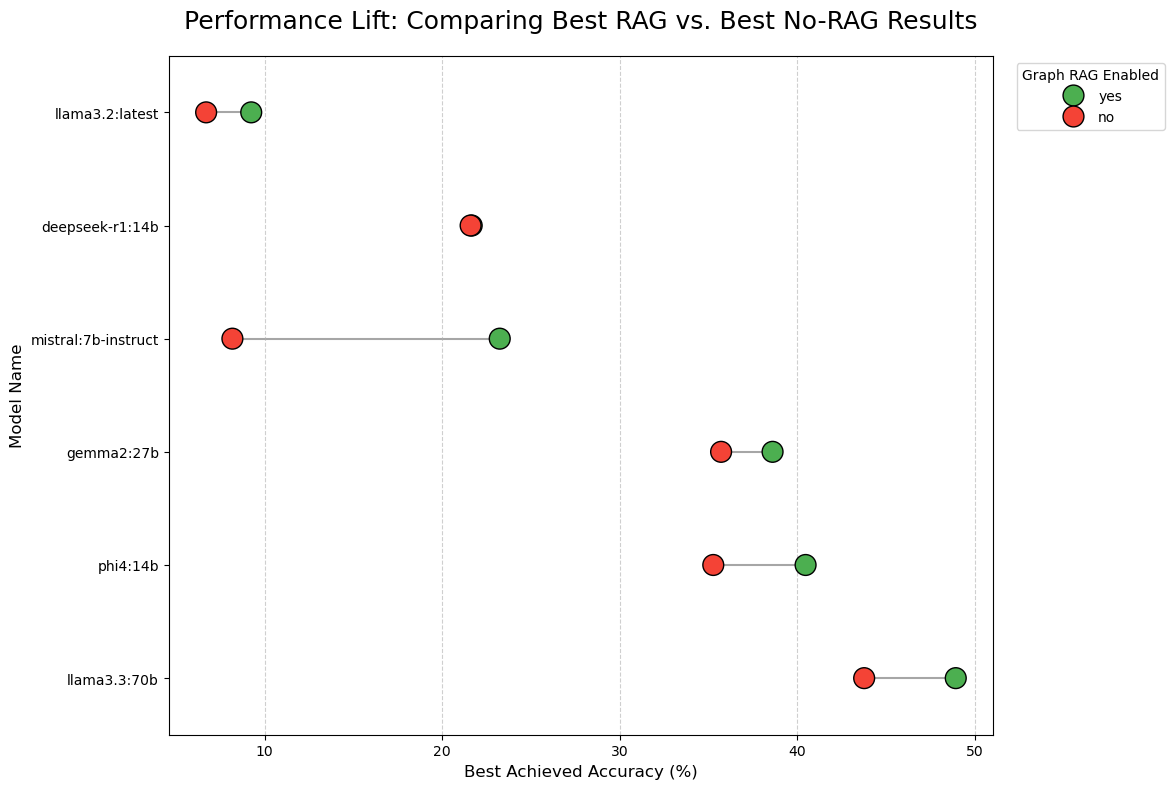

Saved Plot 2 to thesis_visualizations/2_best_vs_best_shift_plot.png


In [115]:
# === PLOT 2: PAIRED STRIP PLOT / DUMBBELL PLOT - Visualizing the "Best Case" Improvement ===
plt.figure(figsize=(14, 8)) # Adjusted figsize for better legend placement
# Sort models by their RAG performance for a cleaner look
sorted_models = comparison_df[comparison_df['kg_rag'] == 'yes'].sort_values('overall_accuracy_%', ascending=True)['model_name']

# Plot the lines connecting the points
for model in sorted_models:
    model_data = comparison_df[comparison_df['model_name'] == model]
    if len(model_data) == 2:
        no_rag_acc = model_data[model_data['kg_rag'] == 'no']['overall_accuracy_%'].values[0]
        rag_acc = model_data[model_data['kg_rag'] == 'yes']['overall_accuracy_%'].values[0]
        plt.plot([no_rag_acc, rag_acc], [model, model], 'o-', color='grey', alpha=0.7, markersize=0, zorder=1)

# Plot the points on top of the lines
sns.stripplot(
    data=comparison_df,
    x='overall_accuracy_%',
    y='model_name',
    hue='kg_rag',
    order=sorted_models,
    palette={'yes': '#4CAF50', 'no': '#F44336'},
    size=15,
    edgecolor='black',
    linewidth=1,
    jitter=0,
    zorder=2
)

plt.title('Performance Lift: Comparing Best RAG vs. Best No-RAG Results', fontsize=18, pad=20)
plt.xlabel('Best Achieved Accuracy (%)', fontsize=12)
plt.ylabel('Model Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# --- THIS IS THE FIX ---
# 1. Move the legend to outside the top-right corner of the plot area.
#    `bbox_to_anchor=(1.02, 1)` places it slightly to the right and at the top.
#    `loc='upper left'` tells the legend's corner to align with that anchor point.
plt.legend(title='Graph RAG Enabled', bbox_to_anchor=(1.02, 1), loc='upper left')

# 2. Adjust the plot layout to make space for the external legend.
#    The `rect` parameter shrinks the plot area slightly to prevent the legend from being cut off.
plt.tight_layout(rect=[0, 0, 0.85, 1]) 
# -------------------------

plt.savefig(os.path.join(plots_dir, '2_best_vs_best_shift_plot.png'))
plt.show()
plt.close()
print(f"Saved Plot 2 to {plots_dir}/2_best_vs_best_shift_plot.png")

In [116]:
try:
    with open(no_rag_json_path, 'r') as f:
        no_rag_rag_json = json.load(f)
    print(f"Successfully loaded RAG subset data from {no_rag_json_path}")
except Exception as e:
    print(f"ERROR loading RAG JSON: {e}")
    no_rag_rag_json = {}

Successfully loaded RAG subset data from results_no_rag/subset_accuracies_report_tasks_reasoning_fct.json


In [117]:
all_subset_data = []
# Process RAG data
for key, accuracies in rag_json.items():
    if len(accuracies) > 10: # Only process full runs
        parts = key.split('_')
        model_name = "_".join(parts[2:-2])
        prompt_id = parts[-2]
        for acc in accuracies:
            all_subset_data.append({"model_name": model_name, "prompt_id": prompt_id, "accuracy": acc, "RAG": "Yes"})

# Process No-RAG data
for key, accuracies in no_rag_rag_json.items():
    if len(accuracies) > 10: # Only process full runs
        parts = key.split('_')
        model_name = "_".join(parts[2:-2])
        prompt_id = parts[-2]
        for acc in accuracies:
            all_subset_data.append({"model_name": model_name, "prompt_id": prompt_id, "accuracy": acc, "RAG": "No"})

if not all_subset_data:
    print("\nERROR: No data with more than 10 subsets found in the JSON files.")
else:
    comparison_subset_df = pd.DataFrame(all_subset_data)

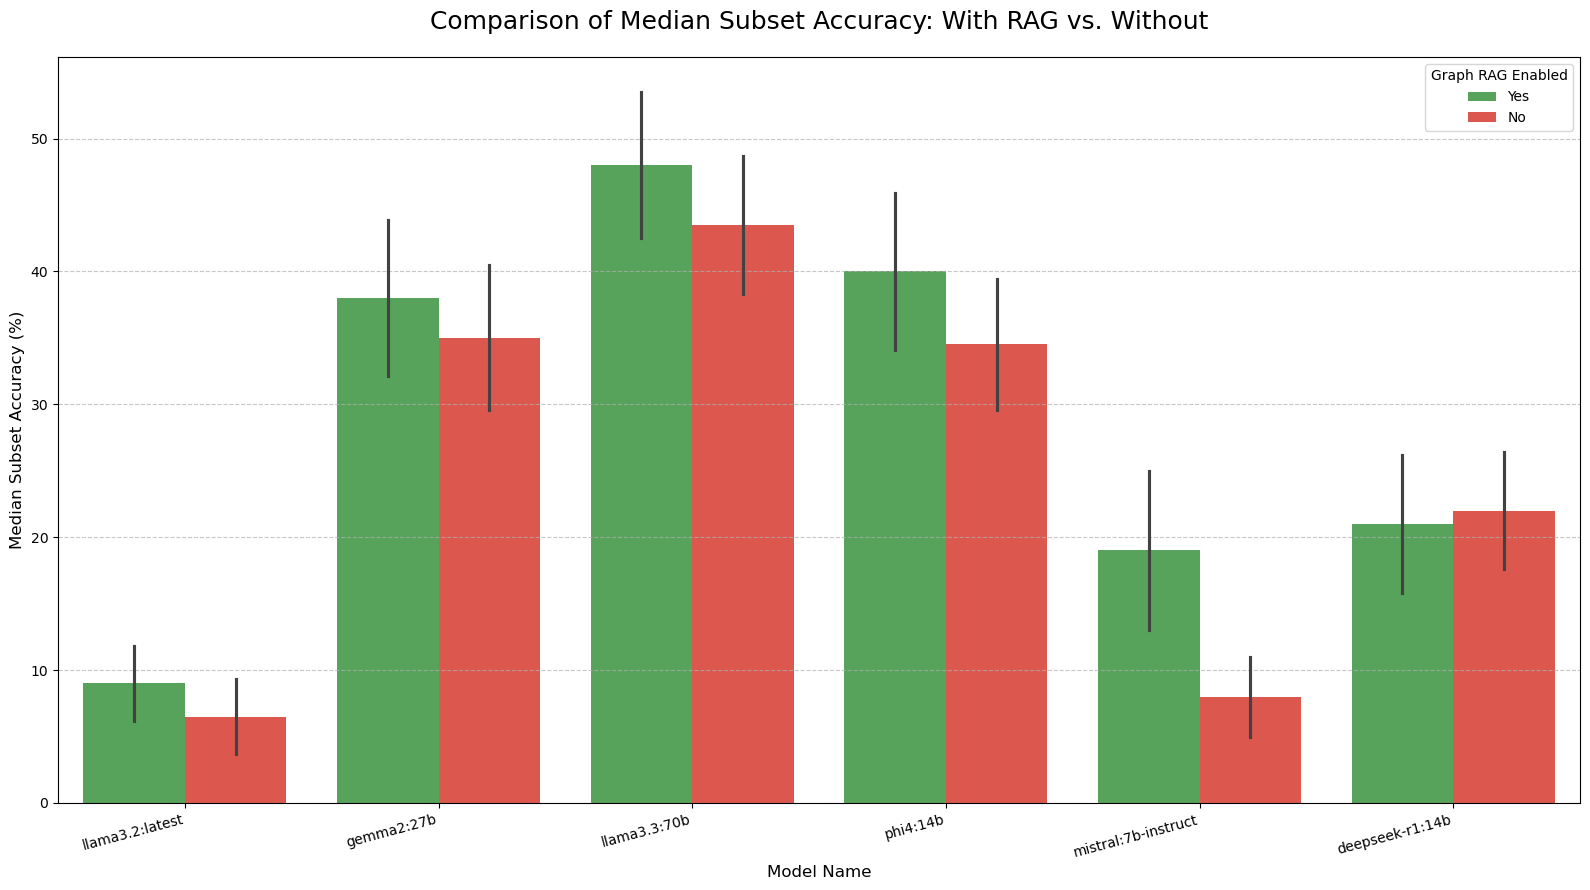

Saved Plot 1 to thesis_visualizations/1_median_comparison_bar.png


In [118]:
# === PLOT 1: GROUPED BAR CHART - Comparing Median Performance ===
plt.figure(figsize=(16, 9))
sns.barplot(
    data=comparison_subset_df,
    x='model_name',
    y='accuracy',
    hue='RAG',
    palette={'Yes': '#4CAF50', 'No': '#F44336'},
    estimator=np.median, # Use median for a more robust central tendency
    errorbar='sd' # Show standard deviation
)
plt.title('Comparison of Median Subset Accuracy: With RAG vs. Without', fontsize=18, pad=20)
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('Median Subset Accuracy (%)', fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.legend(title='Graph RAG Enabled')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '1_median_comparison_bar.png'))
plt.show()
plt.close()
print(f"Saved Plot 1 to {plots_dir}/1_median_comparison_bar.png")

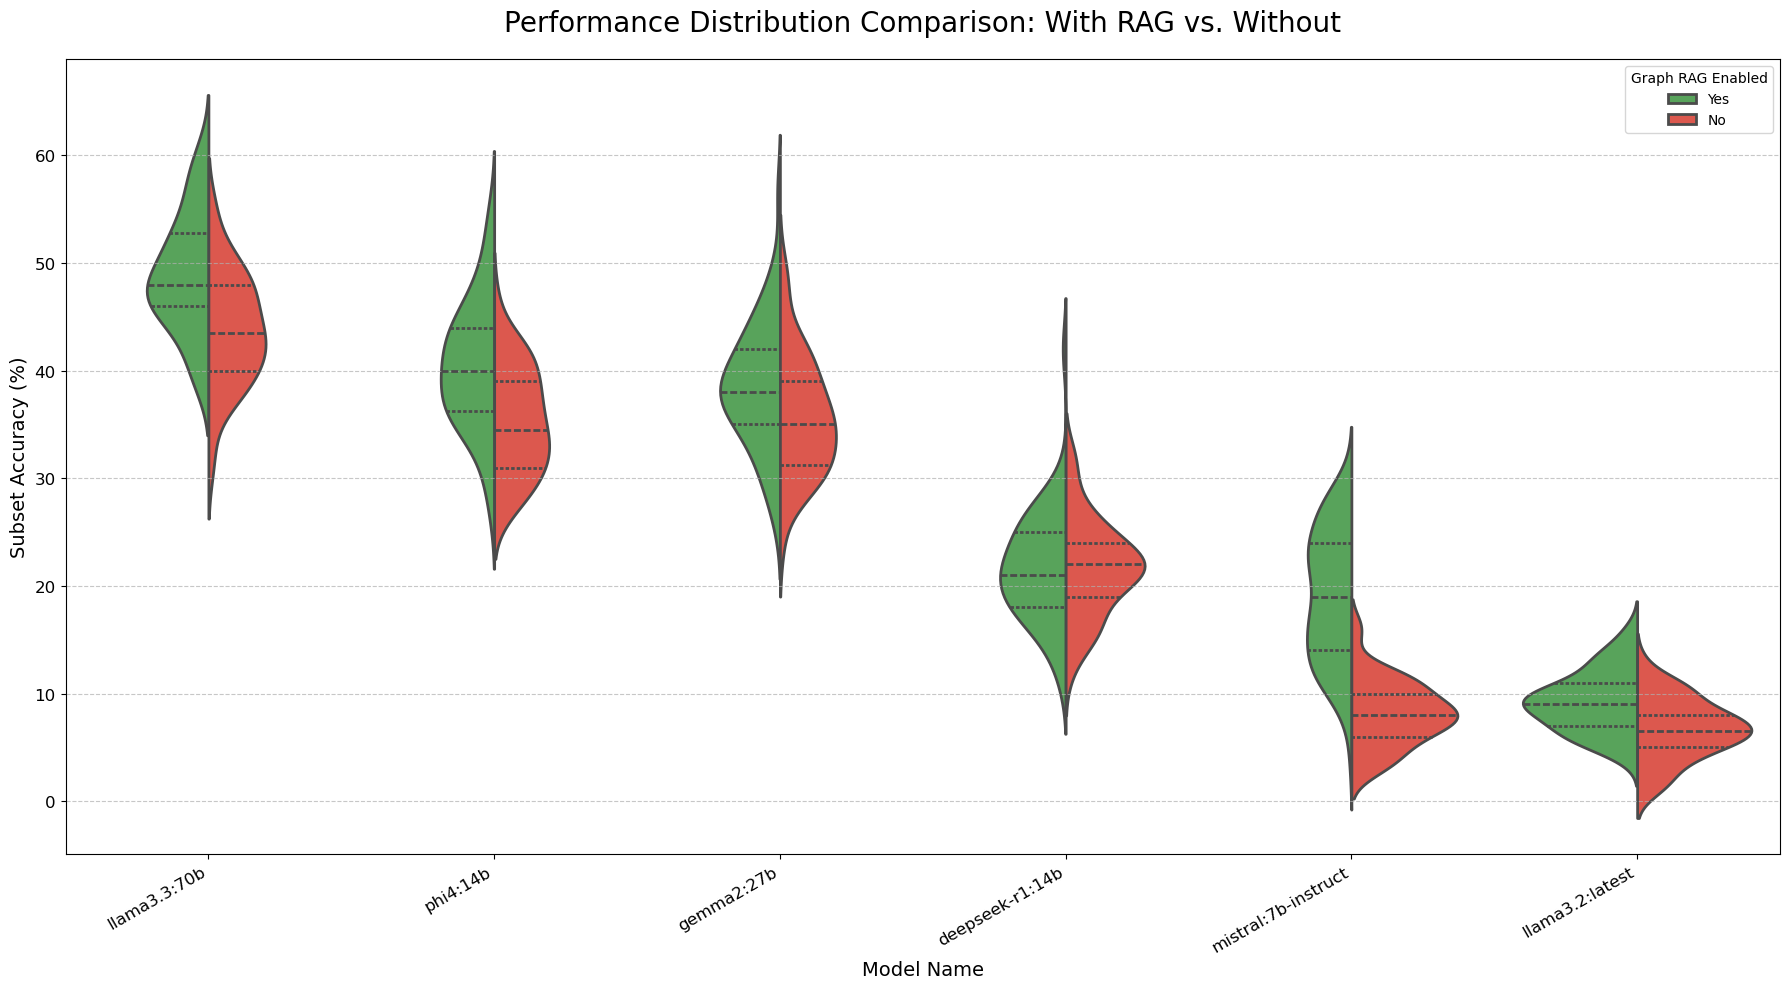

Saved Plot 2 to thesis_visualizations/2_distribution_comparison_violin.png


In [119]:
# === PLOT 2: SPLIT VIOLIN PLOT - Comparing Full Distributions ===
# For a professional-looking chart, we sort the models by their median RAG performance.
median_rag_accuracies = comparison_subset_df[comparison_subset_df['RAG'] == 'Yes'].groupby('model_name')['accuracy'].median().sort_values(ascending=False)
sorted_order = median_rag_accuracies.index

plt.figure(figsize=(18, 10))
sns.violinplot(
    data=comparison_subset_df,
    x='model_name',
    y='accuracy',
    hue='RAG',
    order=sorted_order,
    split=True, # This creates the "half-and-half" violins
    inner='quartile',
    palette={'Yes': '#4CAF50', 'No': '#F44336'},
    linewidth=2
)
plt.title('Performance Distribution Comparison: With RAG vs. Without', fontsize=20, pad=20)
plt.xlabel('Model Name', fontsize=14)
plt.ylabel('Subset Accuracy (%)', fontsize=14)
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Graph RAG Enabled', loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, '2_distribution_comparison_violin.png'))
plt.show()
plt.close()
print(f"Saved Plot 2 to {plots_dir}/2_distribution_comparison_violin.png")